In [1]:
import caesar
import numpy as np
import matplotlib.pyplot as plt
import unyt
from scipy.interpolate import interp1d

# define and load file
#infile = 'data/m50n512_151.hdf5'
#obj = caesar.load(infile)

In [2]:
from functions import *
unit = 'Mpc/h'

##### Resolution analysis

1. change of 2pcf with increasing resolution 

In [3]:
# find file corresponding to redshift z=0.5
caesar.progen.z_to_snap(0.5)

# load file corresponding to redshift z=0.5
infile = 'data/m50n512_125.hdf5'
obj = caesar.load(infile)

yt : [INFO     ] 2023-11-24 14:58:37,737 Opening data/m50n512_125.hdf5
yt : [INFO     ] 2023-11-24 14:58:38,478 Found 61977 halos
yt : [INFO     ] 2023-11-24 14:58:39,117 Found 5685 galaxies


In [4]:
sample_resol9 = [i for i in obj.galaxies if np.log10(i.masses['stellar'])>9]
sample_resol95 = [i for i in obj.galaxies if np.log10(i.masses['stellar'])>9.5]
sample_resol10 = [i for i in obj.galaxies if np.log10(i.masses['stellar'])>10]
sample_resol105 = [i for i in obj.galaxies if np.log10(i.masses['stellar'])>10.5]
print(len(sample_resol9))
print(len(sample_resol95))
print(len(sample_resol10))
print(len(sample_resol105))

3484
2429
1196
417


In [5]:
# projected correlation function
proj_cf_resol9 = calculate_projected_2pcf(
    data= np.array([i.pos.to(unit) for i in sample_resol9]),
    box_size= obj.simulation.boxsize,
    binnumber=10
)
proj_cf_resol95 = calculate_projected_2pcf(
    data= np.array([i.pos.to(unit) for i in sample_resol95]),
    box_size= obj.simulation.boxsize,
    binnumber=10
)
proj_cf_resol10 = calculate_projected_2pcf(
    data= np.array([i.pos.to(unit) for i in sample_resol10]),
    box_size= obj.simulation.boxsize,
    binnumber=10
)
proj_cf_resol105 = calculate_projected_2pcf(
    data= np.array([i.pos.to(unit) for i in sample_resol105]),
    box_size= obj.simulation.boxsize,
    binnumber=10
)

# uncertainty using k-fold method
uncertain9 = find_ptpcf_uncertainty_kfold(
    positions= np.array([i.pos.to(unit) for i in sample_resol9]),
    size_box= obj.simulation.boxsize,
    number_bin= 10
)
uncertain95 = find_ptpcf_uncertainty_kfold(
    positions= np.array([i.pos.to(unit) for i in sample_resol95]),
    size_box= obj.simulation.boxsize,
    number_bin= 10
)
uncertain10 = find_ptpcf_uncertainty_kfold(
    positions= np.array([i.pos.to(unit) for i in sample_resol10]),
    size_box= obj.simulation.boxsize,
    number_bin= 10
)
uncertain105 = find_ptpcf_uncertainty_kfold(
    positions= np.array([i.pos.to(unit) for i in sample_resol105]),
    size_box= obj.simulation.boxsize,
    number_bin= 10
)

/home/oni/master/functions.py:852: RuntimeWarning: divide by zero encountered in divide
  xi = np.divide(hist1,hist2)
/home/oni/master/functions.py:852: RuntimeWarning: invalid value encountered in divide
  xi = np.divide(hist1,hist2)


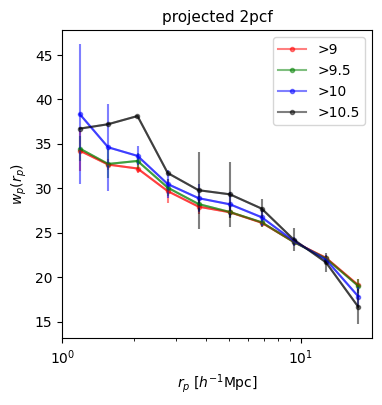

In [6]:
# plot
fig,ax = plt.subplots(figsize=(4, 4))

ax.plot(proj_cf_resol9[0],proj_cf_resol9[1], marker = '.',
        color= 'Red', label='>9', alpha = .5)
ax.errorbar(proj_cf_resol9[0], proj_cf_resol9[1],
        yerr=uncertain9[1], color= 'Red', alpha = .5)
ax.plot(proj_cf_resol95[0],proj_cf_resol95[1], marker = '.',
        color= 'Green', label='>9.5', alpha = .5)
ax.errorbar(proj_cf_resol95[0], proj_cf_resol95[1],
        yerr=uncertain95[1], color= 'Green', alpha = .5)
ax.plot(proj_cf_resol10[0],proj_cf_resol10[1], marker = '.',
        color= 'Blue', label='>10', alpha = .5)
ax.errorbar(proj_cf_resol10[0], proj_cf_resol10[1],
        yerr=uncertain10[1], color= 'Blue', alpha = .5)
ax.plot(proj_cf_resol105[0],proj_cf_resol105[1], marker = '.',
        color= 'Black', label='>10.5', alpha = .5)
ax.errorbar(proj_cf_resol105[0], proj_cf_resol105[1],
        yerr=uncertain105[1], color= 'Black', alpha = .5)
ax.set_xlabel(r"$r_{p} \; [h^{-1} \mathrm{Mpc}]$")
ax.set_ylabel(r"$w_{p} (r_{p})$")
ax.set_title('projected 2pcf', fontsize=11)
#ax.set_ylim(0,2.5)
ax.set_xlim(10e-1,10**(1.3))
ax.set_xscale('log')
ax.legend();

- It seems like galaxies at lower resolution (black) are more strongly clustered than those at higher resolution (red). A significant difference is observed at 10^0.1 Mpc/h especially for galaxy sample with logM_* > 10.5, where there seems to be a small bump.
- Massive galaxies are more clustered than less massive ones. Even with just a very lower number of galaxies, high-mass galaxies present a higher clustering strength than galaxy samples containing a great amount of low-mass galaxies in addition to the high-mass ones.
- Low-mass galaxies are likely not clustered but are rather scattered all around the places.

2. change of 2pcf with different simba samples that mimic boss sample

In [7]:
# find file corresponding to redshift z=0.5
print(caesar.progen.z_to_snap(0.5))

# load file corresponding to redshift z=0.5
infile = 'data/m50n512_125.hdf5'
obj = caesar.load(infile)

yt : [INFO     ] 2023-11-24 14:58:47,286 Opening data/m50n512_125.hdf5
yt : [INFO     ] 2023-11-24 14:58:47,328 Found 61977 halos
yt : [INFO     ] 2023-11-24 14:58:47,340 Found 5685 galaxies


(125, 0.49043513253694404)


In [8]:
# interpolation

# Original distribution
original_x = np.arange(9.95,12.35,0.1)  # Bin mid-points (stellar mass)
original_y = np.array([2,7,2,4,6,
                10,18,37,93,391,
                2656,13936,26446,23258,25919,
                16346,12119,6851,2678,1361,
                383,134,22,10,4])# Counts in each bin (Ngal)

# Compute the normalized cumulative sum, which will serve as the CDF
cdf = np.cumsum(original_y)
cdf = cdf / cdf[-1]  # Normalize to make it a proper CDF

# Create an interpolation function for the CDF
cdf_func = interp1d(original_x, cdf, kind='nearest', bounds_error=False, fill_value=(0, 1))

# get the PDF (probabilities)
pdf = np.diff(cdf, prepend=0) / np.diff(original_x, prepend=0)

# Create an interpolation function for the PDF
pdf_func = interp1d(original_x, pdf, kind='nearest', bounds_error=False, fill_value=(0, 0))

# get galaxy stellar masses
gal_stellar_mass = {i:np.log10(i.masses["stellar"]) for i in obj.galaxies}
# New sample (continuous values)
new_sample = np.array(list(gal_stellar_mass.values()))

# Get the PDF values (probabilities) for each point in the new sample
probabilities = pdf_func(new_sample)
probabilities /= sum(probabilities) # to normalize

In [9]:
# Randomly select indices based on the defined probabilities
# compare different sample sizes
np.random.seed(0)
selected_indices = np.random.choice(len(new_sample), size=len(new_sample)//6, p=probabilities)
sample0 = new_sample[selected_indices]
print(len(sample0))

np.random.seed(0)
selected_indices = np.random.choice(len(new_sample), size=len(new_sample)//4, p=probabilities)
sample1 = new_sample[selected_indices]
print(len(sample1))

np.random.seed(0)
selected_indices = np.random.choice(len(new_sample), size=len(new_sample)//2, p=probabilities)
sample2 = new_sample[selected_indices]
print(len(sample2))

np.random.seed(0)
selected_indices = np.random.choice(len(new_sample), size=len(new_sample), p=probabilities)
sample3 = new_sample[selected_indices]
print(len(sample3))

947
1421
2842
5685


In [10]:
# get the galaxies corresponding to samples
# N//6
gal_sample0 = [k for k,v in gal_stellar_mass.items() for i in sample0 if v == i]
print(len(gal_sample0))
# N//4
gal_sample1 = [k for k,v in gal_stellar_mass.items() for i in sample1 if v == i]
print(len(gal_sample1))
# N//2
gal_sample2 = [k for k,v in gal_stellar_mass.items() for i in sample2 if v == i]
print(len(gal_sample2))
# N
gal_sample3 = [k for k,v in gal_stellar_mass.items() for i in sample3 if v == i]
print(len(gal_sample3))

947
1421
2842
5685


In [11]:
# add random values to the positions
# N//6
delta_n6 = obj.simulation.boxsize.to(unit) / len(gal_sample0)
pos_n6 = np.array([i.pos.to(unit) for i in gal_sample0])
np.random.seed(0)
new_pos_n6 = pos_n6 + np.random.normal(0, delta_n6, (len(gal_sample0),3))

# N//4
delta_n4 = obj.simulation.boxsize.to(unit) / len(gal_sample1)
pos_n4 = np.array([i.pos.to(unit) for i in gal_sample1])
np.random.seed(0)
new_pos_n4 = pos_n4 + np.random.normal(0, delta_n4, (len(gal_sample1),3))

# N//2
delta_n2 = obj.simulation.boxsize.to(unit) / len(gal_sample2)
pos_n2 = np.array([i.pos.to(unit) for i in gal_sample2])
np.random.seed(0)
new_pos_n2 = pos_n2 + np.random.normal(0, delta_n2, (len(gal_sample2),3))

# N
delta_n = obj.simulation.boxsize.to(unit) / len(gal_sample3)
pos_n = np.array([i.pos.to(unit) for i in gal_sample3])
np.random.seed(0)
new_pos_n = pos_n + np.random.normal(0, delta_n, (len(gal_sample3),3))

In [12]:
# check if there are any duplicate values
print(np.any(pos_n6 == new_pos_n6))
print(np.any(pos_n4 == new_pos_n4))
print(np.any(pos_n2 == new_pos_n2))
print(np.any(pos_n == new_pos_n))

False
False
False
False


In [14]:
# projected correlation function
proj_cf_n6 = calculate_projected_2pcf(
    data= new_pos_n6,
    box_size= obj.simulation.boxsize,
    binnumber=10
)
proj_cf_n4 = calculate_projected_2pcf(
    data= new_pos_n4,
    box_size= obj.simulation.boxsize,
    binnumber=10
)
proj_cf_n2 = calculate_projected_2pcf(
    data= new_pos_n2,
    box_size= obj.simulation.boxsize,
    binnumber=10
)
proj_cf_n = calculate_projected_2pcf(
    data= new_pos_n,
    box_size= obj.simulation.boxsize,
    binnumber=10
)

# uncertainty using k-fold method
uncertain_n6 = find_ptpcf_uncertainty_kfold(
    positions= new_pos_n6,
    size_box= obj.simulation.boxsize,
    number_bin= 10
)
uncertain_n4 = find_ptpcf_uncertainty_kfold(
    positions= new_pos_n4,
    size_box= obj.simulation.boxsize,
    number_bin= 10
)
uncertain_n2 = find_ptpcf_uncertainty_kfold(
    positions= new_pos_n2,
    size_box= obj.simulation.boxsize,
    number_bin= 10
)
uncertain_n = find_ptpcf_uncertainty_kfold(
    positions= new_pos_n,
    size_box= obj.simulation.boxsize,
    number_bin= 10
)

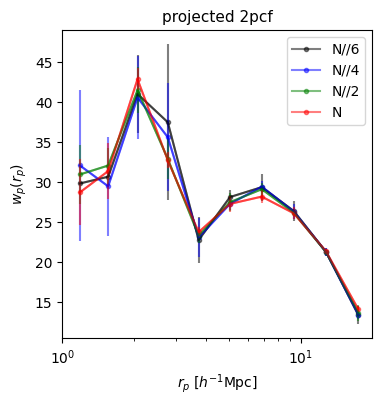

In [15]:
# plot
fig,ax = plt.subplots(figsize=(4, 4))

ax.plot(proj_cf_n6[0],proj_cf_n6[1], marker = '.',
        color= 'Black', label='N//6', alpha = .5)
ax.errorbar(proj_cf_n6[0], proj_cf_n6[1],
        yerr=uncertain_n6[1], color= 'Black', alpha = .5)
ax.plot(proj_cf_n4[0],proj_cf_n4[1], marker = '.',
        color= 'Blue', label='N//4', alpha = .5)
ax.errorbar(proj_cf_n4[0], proj_cf_n4[1],
        yerr=uncertain_n4[1], color= 'Blue', alpha = .5)
ax.plot(proj_cf_n2[0],proj_cf_n2[1], marker = '.',
        color= 'Green', label='N//2', alpha = .5)
ax.errorbar(proj_cf_n2[0], proj_cf_n2[1],
        yerr=uncertain_n2[1], color= 'Green', alpha = .5)
ax.plot(proj_cf_n[0],proj_cf_n[1], marker = '.',
        color= 'Red', label='N', alpha = .5)
ax.errorbar(proj_cf_n[0], proj_cf_n[1],
        yerr=uncertain_n[1], color= 'Red', alpha = .5)
ax.set_xlabel(r"$r_{p} \; [h^{-1} \mathrm{Mpc}]$")
ax.set_ylabel(r"$w_{p} (r_{p})$")
ax.set_title('projected 2pcf', fontsize=11)
#ax.set_ylim(0,2.5)
ax.set_xlim(10e-1,10**(1.3))
ax.set_xscale('log')
ax.legend();

- The lower resolution samples (black and blue) show a small bump at $10^{0.15}Mpc/h$ which is not seen in higher resolution samples (green and red)
- There is no other significant difference between different resolutions.